#### Imports

In [1]:
import json
import math
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import subprocess
import networkx as nx
from networkx.algorithms import bipartite
from pathlib import Path  
import matplotlib.pyplot as plt
import locale
import os
import subprocess
import codecs
locale.setlocale(locale.LC_ALL, 'de-DE.utf-8')

'de-DE.utf-8'

#### Funktion für die Erzeugung der dot-Datei:

In [2]:
def graphToDot(graph=None, outfile=None):
   if graph == None:
      print ('Missing graph specification.')
      return
   if outfile == None:
      print ('Missing output file specification.')
      return
   dot = 'graph {\ngraph[rankdir="LR", outputorder="edgesfirst"]\nnode[fontname="Arial", fontsize=120, shape=circle, style=filled, fixedsize=shape];\n'
   for u,v,att in graph.edges(data=True):
      x = [u,v]
      x.sort(key=locale.strxfrm)
      u = x[0]
      v = x[1]
      dot += u+' -- '+v+' [penwidth='+str(att.get('weight'))
      dot += ', id='+'"'+u+"--"+v+'"'
      if att.get('weight') > 1:
            dot += ', color=Red]\n'
      else:
            dot += ']\n'
   for u,att in graph.nodes(data=True):
      dot += u+' [width=' + str(1+3*math.sqrt(att.get('occ'))) +  ']\n'
   dot += '}'
   with codecs.open(outfile, 'w', encoding = 'utf8') as file:
      file.write(dot)
   return

#### Funktion für die Berechnung der Keywords und die Erstellung des Graphen:

In [11]:
def graph_maker(texts, threshold, dot_file, svg_file):

   # Read stopwords
   file = 'C:/Users/nlutt/myOrpheana/03 tools/stopw_german_sorted'
   with open(file, 'r', encoding='utf-8') as stop:
      stopw = stop.read()
   stopw = stopw.split('\n')

   # Fit and transform the article texts using TF-IDF
   vectorizer = TfidfVectorizer(stop_words=stopw)
   tfidf_matrix = vectorizer.fit_transform(texts)
   
   # Create a Pandas DataFrame from tfidf_matrix and reshape it
   text_titles = [f"article_{str(i)}" for i in range(len(texts))]
   feature_names = vectorizer.get_feature_names_out()
   tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), index=text_titles, columns=feature_names)
   tfidf_df = tfidf_df.stack().reset_index()
   tfidf_df = tfidf_df.rename(columns={0:'tfidf', 'level_0': 'article','level_1': 'feature'})  

   # Set threshold for TF-IDF values and determine remaining features
   thres_tfidf = tfidf_df[tfidf_df['tfidf'] > threshold]
   print ('count rows in reduced tf-idf matrix: ', len(thres_tfidf.index))
   
   # compute document frequency
   occ = thres_tfidf['feature'].value_counts()
   occ_dict = occ.to_dict()
   #print ('feature occurences: ', occ_dict)

   # Make semantic graph
   B = nx.Graph(created_by='fruschtique')
   X = nx.Graph(created_by='fruschtique')
   top    = thres_tfidf['article'].unique()
   bottom = thres_tfidf['feature'].unique()
   e_list = []
   for index, row in thres_tfidf.iterrows():
      e_list.append((row['article'], row['feature']))
   B.add_nodes_from(top, bipartite=0)
   B.add_nodes_from(bottom, bipartite=1)
   B.add_edges_from(e_list)
   X = bipartite.weighted_projected_graph(B, bottom)

   # Add attributes to nodes 
   nx.set_node_attributes(X, occ_dict, 'occ')
   print ('count nodes: ',len(X.nodes))
   #for n in X.nodes(data=True):
   #   print (n)
   print ('count edges: ', len(X.edges))
   #for e in X.edges(data=True):
   #   print (e) 

   # Generate initial graph
   pos = nx.spring_layout(X)
   nx.draw(X, pos, with_labels=True)   
   plt.show()

   # Gnerate SVG graph and save it
   outfile = dot_file
   graphToDot(X, outfile)
   infile  = outfile
   print ('in ', infile)
   outfile = svg_file
   print ('out', outfile)
   sfdp = "C:/Program Files/Graphviz/bin/sfdp.exe"
   subprocess.run ([f"{sfdp}", f"{infile}", '-o', f"{outfile}", 'Goverlap=prism', '-Tsvg'])

#### Articles aus 1996-Holländer-Wagner-Nürnberg.json:

count rows in reduced tf-idf matrix:  46
count nodes:  42
count edges:  203


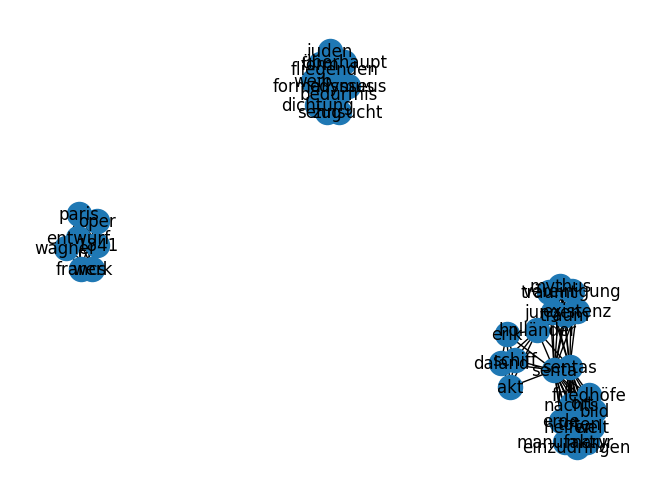

in  C:/Users/nlutt/myOrpheana/10 studies/first/first.dot
out C:/Users/nlutt/myOrpheana/10 studies/first/first.svg


In [12]:
# Read and parse the JSON file
file = 'C:/Users/nlutt/myOrpheana/06 orphs - working copies/1996-Holländer-Wagner-Nürnberg.json'
with open(file, 'r', encoding='utf-8') as f:
    orph = json.load(f)
# Print the parsed data
#print (orph['articles'][3]['author']) 
texts = [article['text'] for article in orph['articles']]
dot_file = r'C:/Users/nlutt/myOrpheana/10 studies/first/first.dot'
svg_file = r'C:/Users/nlutt/myOrpheana/10 studies/first/first.svg'
threshold = 0.12
graph_maker (texts, threshold, dot_file, svg_file)

#### Berechnung der Kosinus-Ähnlichkeit

In [13]:
def cosine_sim (texts,index):
  # Read stopwords
  file = 'C:/Users/nlutt/Documents/german_sorted'
  with open(file, 'r', encoding='utf-8') as stop:
    stopw = stop.read()
  stopw = stopw.split('\n')
  count_vectorizer = CountVectorizer(stop_words=stopw)
  matrix = count_vectorizer.fit_transform(texts)
  feature_names = count_vectorizer.get_feature_names_out()
  df = pd.DataFrame(matrix.toarray(), index=index, columns=feature_names)
  cs = cosine_similarity(df)
  cs_df = pd.DataFrame(cs, index=index, columns=index)
  print(cs_df)

#### Ähnlichkeit von zwei Artikeln

In [14]:
# Read and parse the corpus file
file = 'C:/Users/nlutt/myOrpheana/10 studies/second/second_corpus.json'
with open(file, 'r', encoding='utf-8') as f:
    corpus = json.load(f)

In [ ]:
 
texts = [article['text'] for article in corpus['articles']]
index = [article['author'] for article in corpus['articles']]
cosine_sim (texts,index)